# Geo Classifier 🏞️

## Problem 🤔

Classify images of natural scenes into 6 categories: Buildings, Forests, Glaciers, Mountains, Seas, or Streets.

## Data 📊

[Intel Image Classification Dataset from Kaggle](https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data)

## Target 🎯

90% Accuracy

## Features ✨

**id** -> image id of the geographic location

**geo_cat** -> category of the geographic scene out of the 6: buildings, forests, glaciers, moutains, seas or streets

## Workspace Setup 🛠️

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os
import kagglehub

In [6]:
# set matplotlib styling
plt.style.use("ggplot")

In [7]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
os.environ["KAGGLEHUB_CACHE"] = "/content/drive/MyDrive/kaggle_datasets"

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

Path to dataset files: /content/drive/MyDrive/kaggle_datasets/datasets/puneet6060/intel-image-classification/versions/2


In [9]:
# @title Data Related Global Vars 🌐
BATCH_SIZE = 32
IMAGE_SIZE = (150, 150)

In [10]:
# train datase
train_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_train/seg_train", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical")

# test and validation datasets
test_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_test/seg_test", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", validation_split=0.2, subset="training", seed=42)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_test/seg_test", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", validation_split=0.2, subset="validation", seed=42)

# pred dataset
preds_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_pred/seg_pred", labels=None, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Using 2400 files for training.
Found 3000 files belonging to 6 classes.
Using 600 files for validation.
Found 7301 files.


In [11]:
train_ds.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None))>

In [12]:
train_ds.element_spec

(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 6), dtype=tf.float32, name=None))

## EDA 🔎

In [13]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [14]:
# from collections import Counter

# counts = Counter([])
# for _, labels in train_ds:
#     for label in labels:
#         counts.update(np.where(label.numpy() == 1)[0].tolist())

# class_distributions = {class_names[i]: value for i, value in dict(counts).items()}
# print("Class distribution:", class_distributions)

class_distributions = {'buildings': 2191, 'glacier': 2404, 'forest': 2271, 'street': 2382, 'mountain': 2512, 'sea': 2274}

print(f"Class distribution: {class_distributions}")

Class distribution: {'buildings': 2191, 'glacier': 2404, 'forest': 2271, 'street': 2382, 'mountain': 2512, 'sea': 2274}


In [15]:
class_distribution_df = pd.DataFrame(list(class_distributions.items()), columns=['Class', 'Count'])
class_distribution_df

,Class,Count
0,buildings,2191
1,glacier,2404
2,forest,2271
3,street,2382
4,mountain,2512
5,sea,2274


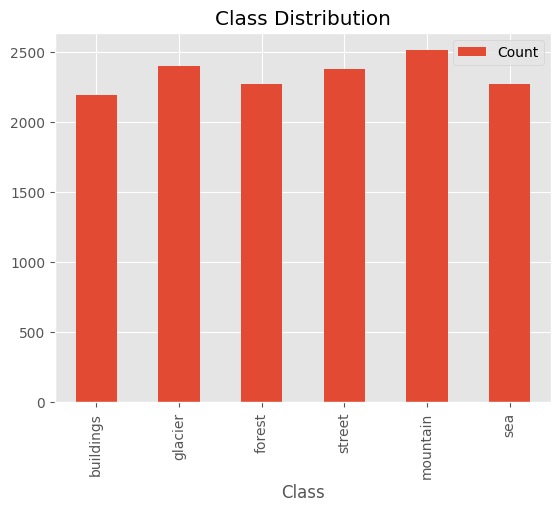

In [16]:
class_distribution_df.plot(kind='bar', x='Class', y='Count', title='Class Distribution')
plt.show()

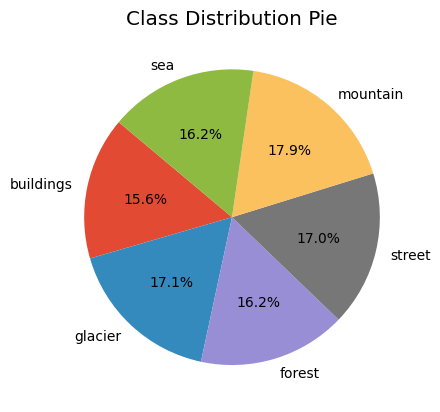

In [17]:
plt.pie(class_distributions.values(), labels=class_distributions.keys(), autopct="%1.1f%%", startangle=140)
plt.title("Class Distribution Pie")
plt.show()

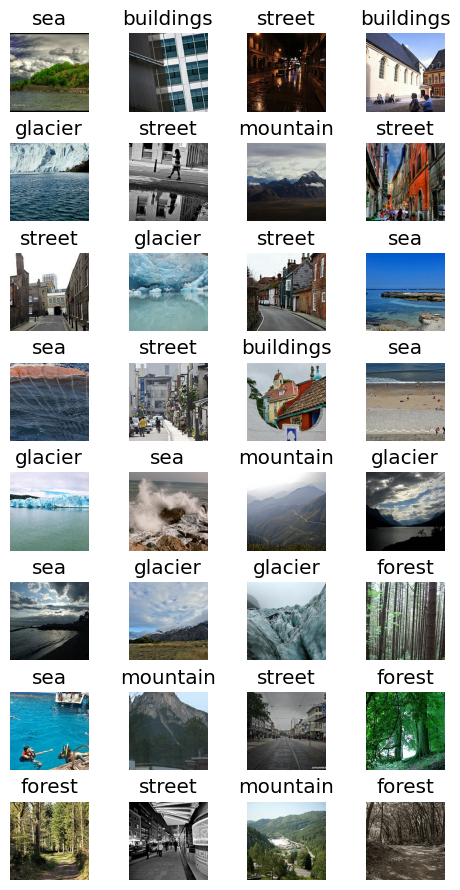

In [18]:
plt.figure(figsize=(5, 9))
for images, labels in train_ds.take(1):  # take one batch
    for i in range(BATCH_SIZE):  # show first 9 images
        plt.subplot(8, 4, i + 1)

        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.axis("off")

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.where(labels[i] == 1)[0][0]])
    break

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

In [19]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Image shape: (32, 150, 150, 3)
Label shape: (32, 6)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>


## Data Preprocessing ⚙️

In [20]:
augmentation_model = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(factor=0.15),  # randomly rotate images (factor is a fraction of pi radians)
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),  # randomly zoom images
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # flips the image
])

augmented_train_ds = train_ds.map(lambda x, y: (augmentation_model(x, training=True), y))

## Modelling Global Vars 🌐

In [21]:
INPUT_SHAPE = [150, 150, 3]
OUTPUT_SHAPE = len(class_distributions.keys())
N_EPOCHS = 128

MODEL_SAVE_PATH = "/content/drive/MyDrive/trained_models/geo_classifier/"

In [22]:
def get_model_checkpoint_callback(model_name):
    return tf.keras.callbacks.ModelCheckpoint(
        filepath=f"/content/drive/MyDrive/google_colab_model_checkpoints/geo_classifier/{model_name}.weights.h5",
        save_weights_only=True,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True
    )

In [23]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
import tensorflow as tf

def analyze_model_performance(model, test_ds, class_names):
    """
    Comprehensive analysis of model performance including confusion matrix,
    per-class metrics, and misclassified examples visualization.
    """
    # Get predictions and true labels
    all_predictions = []
    all_labels = []

    test_ds = test_ds.unbatch().batch(32) # reset the dataset

    for images, labels in test_ds:
        # get predictions for this batch
        predictions = model.predict(images, verbose=0)

        # store predictions and labels
        all_predictions.append(predictions)
        all_labels.append(labels.numpy())

    # concatenate all batches
    y_pred_probs = np.concatenate(all_predictions)
    y_true_probs = np.concatenate(all_labels)
    # convert to class labels
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    y_true_labels = np.argmax(y_true_probs, axis=1)

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))

    # 1. Confusion Matrix
    ax1 = plt.subplot(2, 2, 1)
    conf_matrix = tf.math.confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrix_norm = conf_matrix.numpy().astype('float') / conf_matrix.numpy().sum(axis=1)[:, np.newaxis]

    sns.heatmap(conf_matrix_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title('Normalized Confusion Matrix')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')

    # 2. Per-class Accuracy
    ax2 = plt.subplot(2, 2, 2)
    class_accuracies = conf_matrix_norm.diagonal()
    bars = ax2.bar(class_names, class_accuracies)
    ax2.set_title('Per-class Accuracy')
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Accuracy')
    plt.xticks(rotation=45)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

    # 3. Confidence Distribution
    ax3 = plt.subplot(2, 2, 3)
    correct_conf = y_pred_probs[y_pred_labels == y_true_labels].max(axis=1)
    incorrect_conf = y_pred_probs[y_pred_labels != y_true_labels].max(axis=1)

    sns.histplot(data=correct_conf, label='Correct Predictions',
                alpha=0.5, color='green', ax=ax3)
    sns.histplot(data=incorrect_conf, label='Incorrect Predictions',
                alpha=0.5, color='red', ax=ax3)
    ax3.set_title('Prediction Confidence Distribution')
    ax3.set_xlabel('Confidence')
    ax3.set_ylabel('Count')
    ax3.legend()

    # 4. Most Confused Pairs
    ax4 = plt.subplot(2, 2, 4)
    conf_matrix_without_diag = conf_matrix.numpy()
    np.fill_diagonal(conf_matrix_without_diag, 0)
    most_confused = []

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j:
                most_confused.append((class_names[i], class_names[j],
                                    conf_matrix_without_diag[i, j]))

    most_confused.sort(key=lambda x: x[2], reverse=True)
    top_confused = most_confused[:5]

    pairs = [f"{true}\n→{pred}" for true, pred, _ in top_confused]
    values = [count for _, _, count in top_confused]

    bars = ax4.bar(pairs, values)
    ax4.set_title('Top 5 Most Confused Class Pairs')
    ax4.set_xlabel('True → Predicted')
    ax4.set_ylabel('Count')
    plt.xticks(rotation=45)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

    return {
        'confusion_matrix': conf_matrix,
        'class_accuracies': class_accuracies,
        'correct_confidences': correct_conf,
        'incorrect_confidences': incorrect_conf,
        'most_confused_pairs': most_confused
    }

In [34]:
def visualize_history_metric(his_obj, metric):
    """
        Plots how a specific metric changes with each epoch.
    """
    plt.plot(his_obj.history[metric], "bo--", label=metric)
    plt.plot(his_obj.history["val_"+metric], "ro--", label="val_"+metric)

    plt.title(f"{metric} vs val_{metric}")
    plt.xlabel("epochs")
    plt.ylabel(metric)
    plt.legend()

## Basic CNN Modelling 💡

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling, Input

def build_and_compile_vanilla_cnn():
    model = Sequential()

    model.add(Input(INPUT_SHAPE))
    model.add(Rescaling(1./255))

    model.add(Conv2D(32, (3, 3), activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(32, (3, 3), activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    model.add(Dense(128, activation="relu"))

    model.add(Dense(OUTPUT_SHAPE, activation="softmax"))

    model.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

    return model

In [ ]:
vanilla_cnn_model = build_and_compile_vanilla_cnn()

history = vanilla_cnn_model.fit(
    augmented_train_ds,
    epochs=N_EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping, get_model_checkpoint_callback("vanilla_cnn")]
)

Epoch 1/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 2034s 5s/step - accuracy: 0.4060 - loss: 3.2401 - val_accuracy: 0.4050 - val_loss: 4.0641
Epoch 2/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 99s 225ms/step - accuracy: 0.5002 - loss: 1.3183 - val_accuracy: 0.4850 - val_loss: 1.3023
Epoch 3/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 98s 222ms/step - accuracy: 0.5399 - loss: 1.1895 - val_accuracy: 0.3350 - val_loss: 2.1769
Epoch 4/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 141s 221ms/step - accuracy: 0.5509 - loss: 1.1347 - val_accuracy: 0.4550 - val_loss: 1.5883
Epoch 5/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 142s 222ms/step - accuracy: 0.5590 - loss: 1.1016 - val_accuracy: 0.3817 - val_loss: 1.9084


In [ ]:
vanilla_cnn_model.evaluate(test_ds)

75/75 ━━━━━━━━━━━━━━━━━━━━ 401s 5s/step - accuracy: 0.3801 - loss: 1.9473


[2.0093743801116943, 0.3558333218097687]

In [ ]:
vanilla_cnn_model.save(MODEL_SAVE_PATH + "vanilla_cnn_model.keras")

In [ ]:
y_pred_probs = vanilla_cnn_model.predict(test_ds)

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step


In [ ]:
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred

array([4, 2, 1, ..., 5, 1, 1])

#### Training History 📈

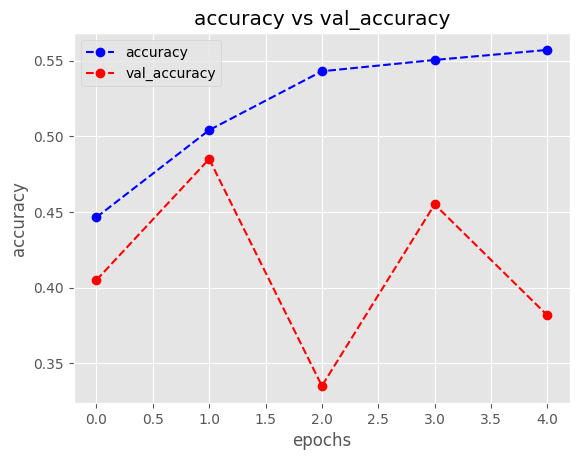

In [ ]:
visualize_history_metric(history, "accuracy")

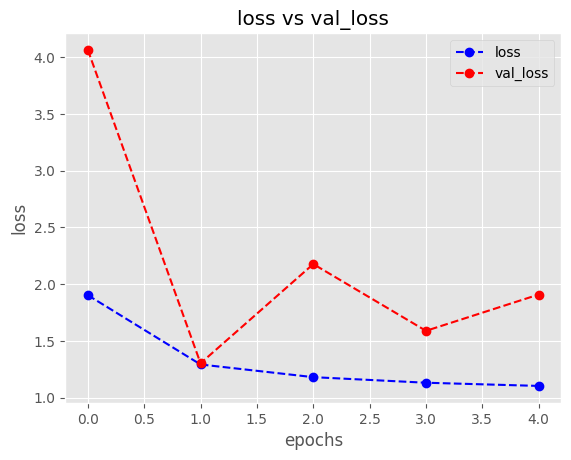

In [ ]:
visualize_history_metric(history, "loss")

### Error Analysis ⚠️

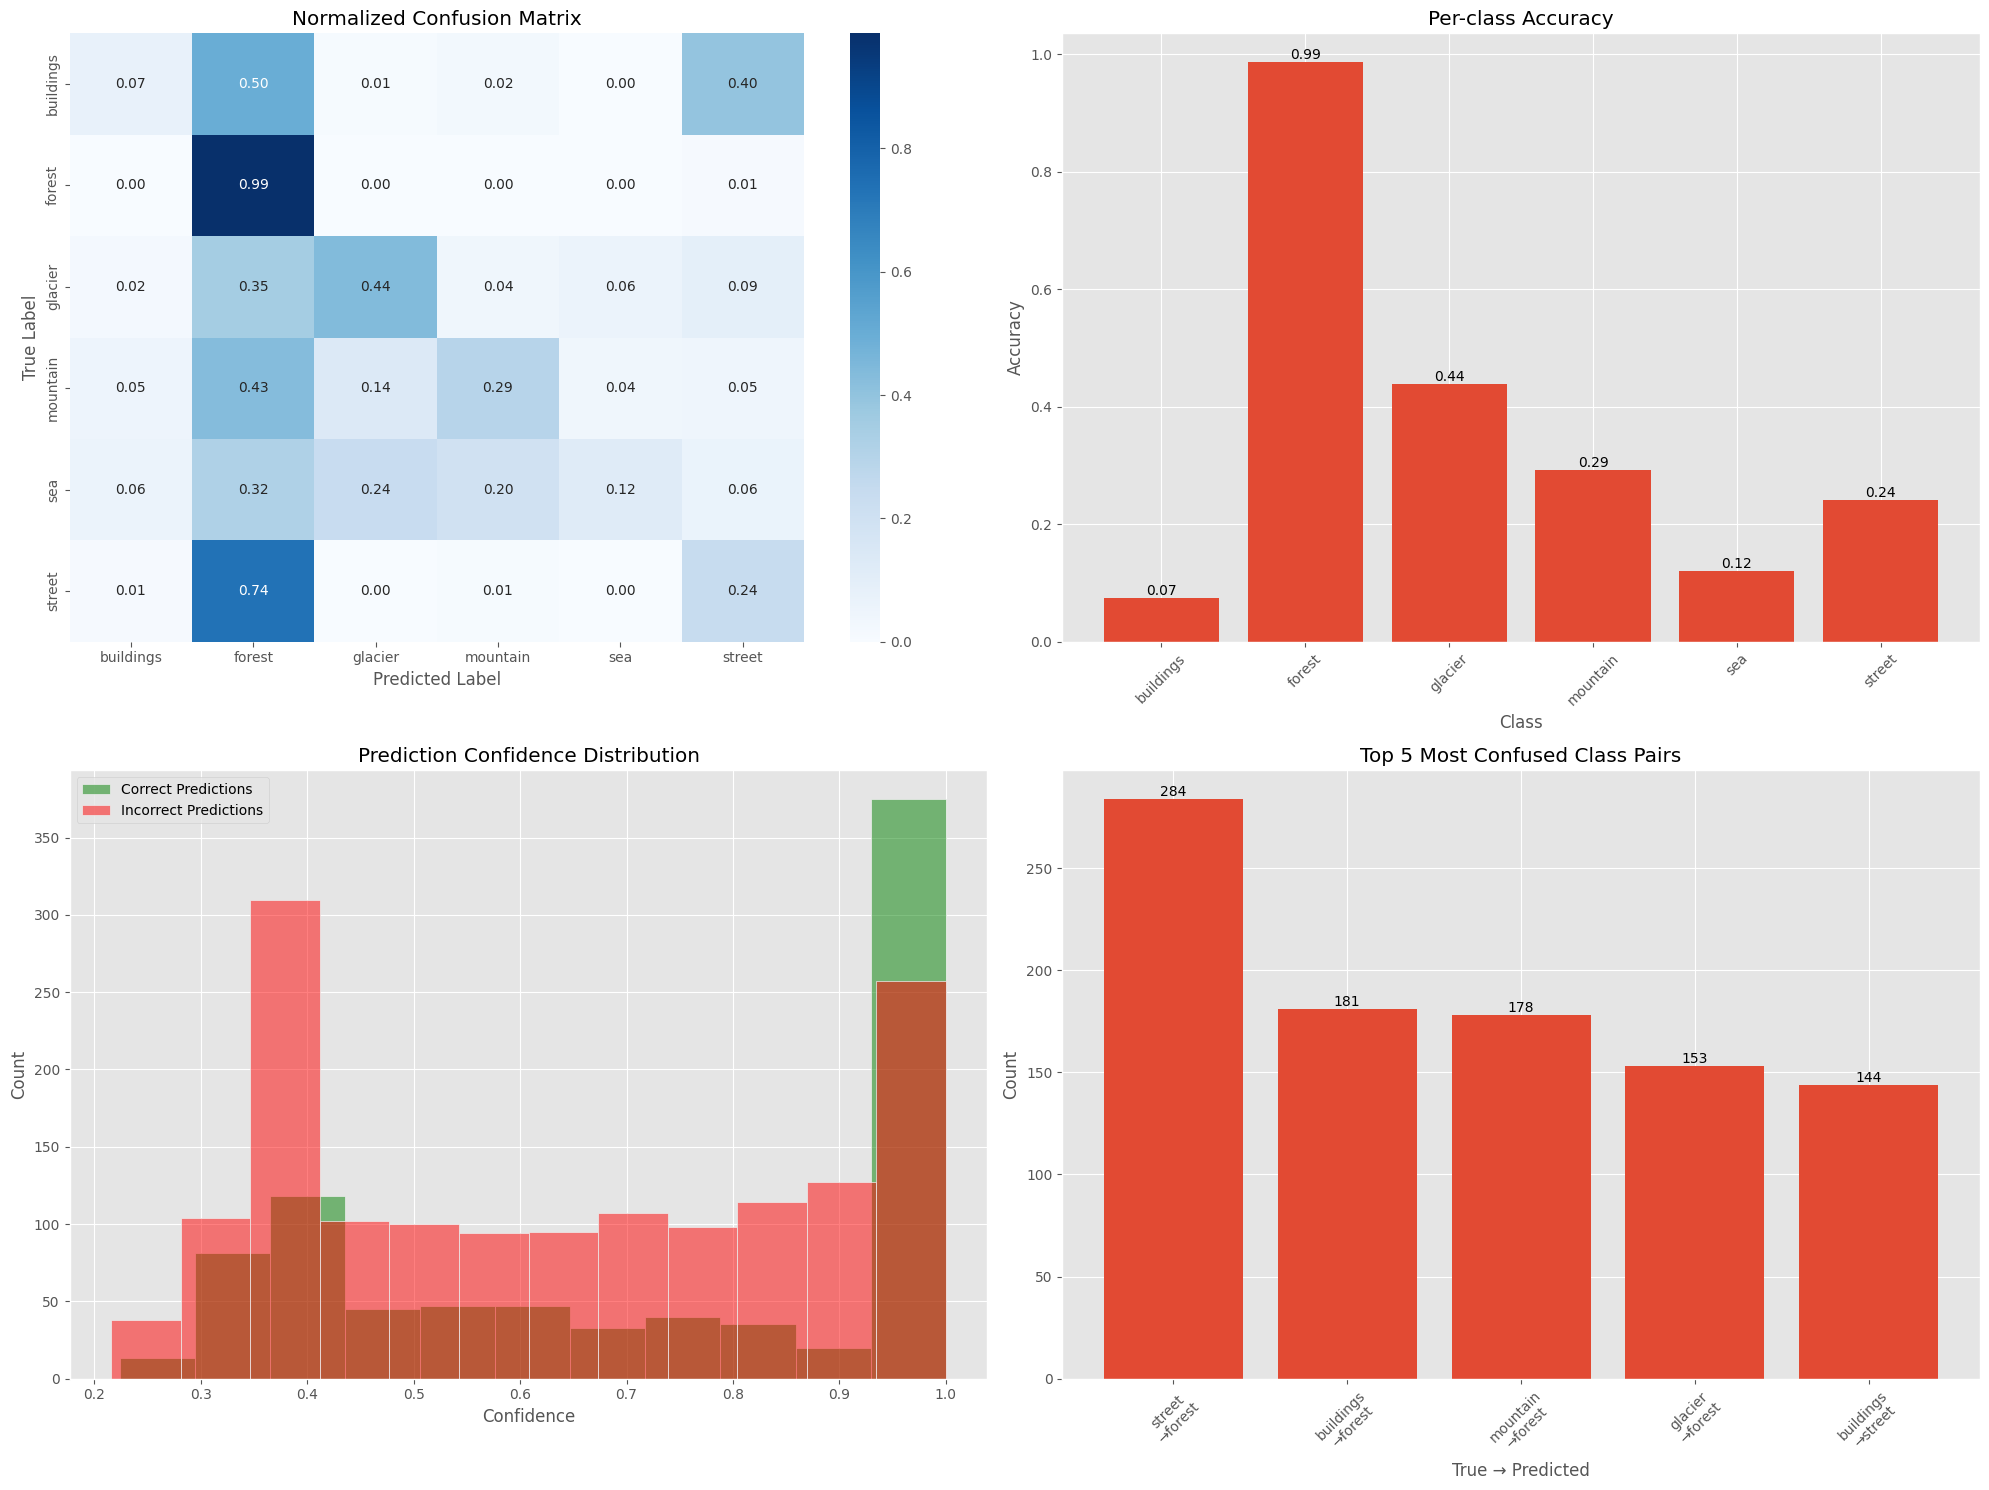


Classification Report:
              precision    recall  f1-score   support

   buildings       0.31      0.07      0.12       364
      forest       0.28      0.99      0.44       374
     glacier       0.54      0.44      0.49       440
    mountain       0.51      0.29      0.37       413
         sea       0.55      0.12      0.20       423
      street       0.28      0.24      0.26       386

    accuracy                           0.36      2400
   macro avg       0.41      0.36      0.31      2400
weighted avg       0.42      0.36      0.32      2400



In [ ]:
vanilla_cnn_analysis_results = analyze_model_performance(vanilla_cnn_model, test_ds, class_names)

## ResNet Modelling 🥅

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling, Input

def build_resnet(input_shape=(150, 150, 3), num_classes=6):
    # Get the base model with preprocessing layer included
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.applications.resnet50.preprocess_input(inputs) # ResNet50's preprocessing layer
    x = base_model(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

resnet_model = build_resnet()
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 150, 150, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item (GetItem)        │ (None, 150, 150)       │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_1 (GetItem)      │ (None, 150, 150)       │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_2 (GetItem)      │ (None, 150, 150)       │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stack (Stack)             │ (None, 150, 150, 3)    │              0 │ get_item[0][0],        │
│                           │                        │                │ get_item_1[0][0],      │
│                           │                        │                │ get_item_2[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 150, 150, 3)    │              0 │ stack[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resnet50 (Functional)     │ (None, 5, 5, 2048)     │     23,587,712 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 2048)           │              0 │ resnet50[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 256)            │        524,544 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 256)            │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 6)              │          1,542 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = resnet_model.fit(
    augmented_train_ds,
    epochs=N_EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping, get_model_checkpoint_callback("resnet_model")]
)

Epoch 1/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 135s 279ms/step - accuracy: 0.6945 - loss: 0.8326 - val_accuracy: 0.9017 - val_loss: 0.2940
Epoch 2/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 118s 236ms/step - accuracy: 0.8603 - loss: 0.3759 - val_accuracy: 0.9067 - val_loss: 0.2729
Epoch 3/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 142s 236ms/step - accuracy: 0.8759 - loss: 0.3435 - val_accuracy: 0.9233 - val_loss: 0.2530
Epoch 4/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 141s 235ms/step - accuracy: 0.8835 - loss: 0.3135 - val_accuracy: 0.9183 - val_loss: 0.2652
Epoch 5/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 100s 228ms/step - accuracy: 0.8928 - loss: 0.2961 - val_accuracy: 0.9200 - val_loss: 0.2559
Epoch 6/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 103s 233ms/step - accuracy: 0.8938 - loss: 0.2904 - val_accuracy: 0.9100 - val_loss: 0.2573


In [ ]:
resnet_model.evaluate(test_ds)

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.9135 - loss: 0.2365


[0.24325115978717804, 0.9125000238418579]

In [ ]:
resnet_model.save(MODEL_SAVE_PATH + "resnet_model.keras")

### Training History 📈

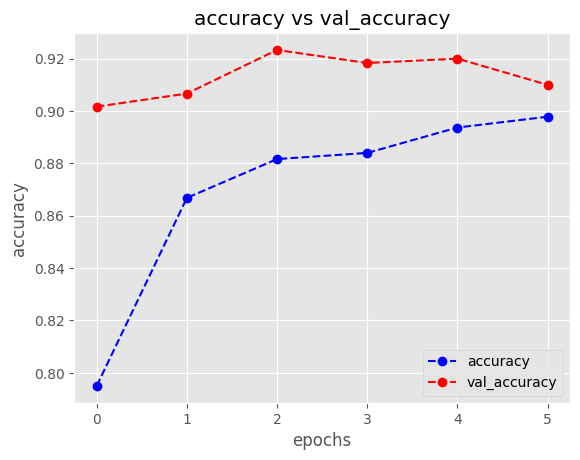

In [ ]:
visualize_history_metric(history, "accuracy")

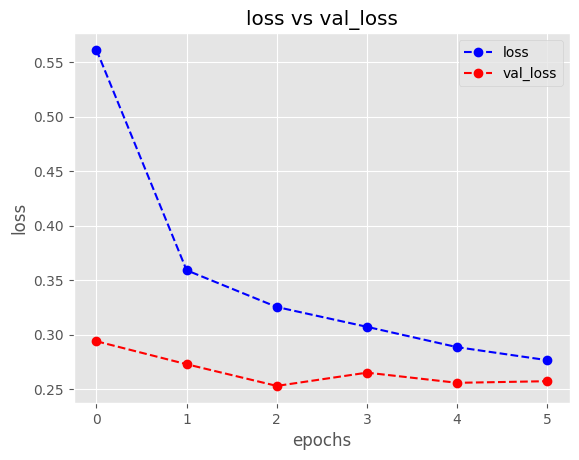

In [ ]:
visualize_history_metric(history, "loss")

### Error Analysis ⚠️

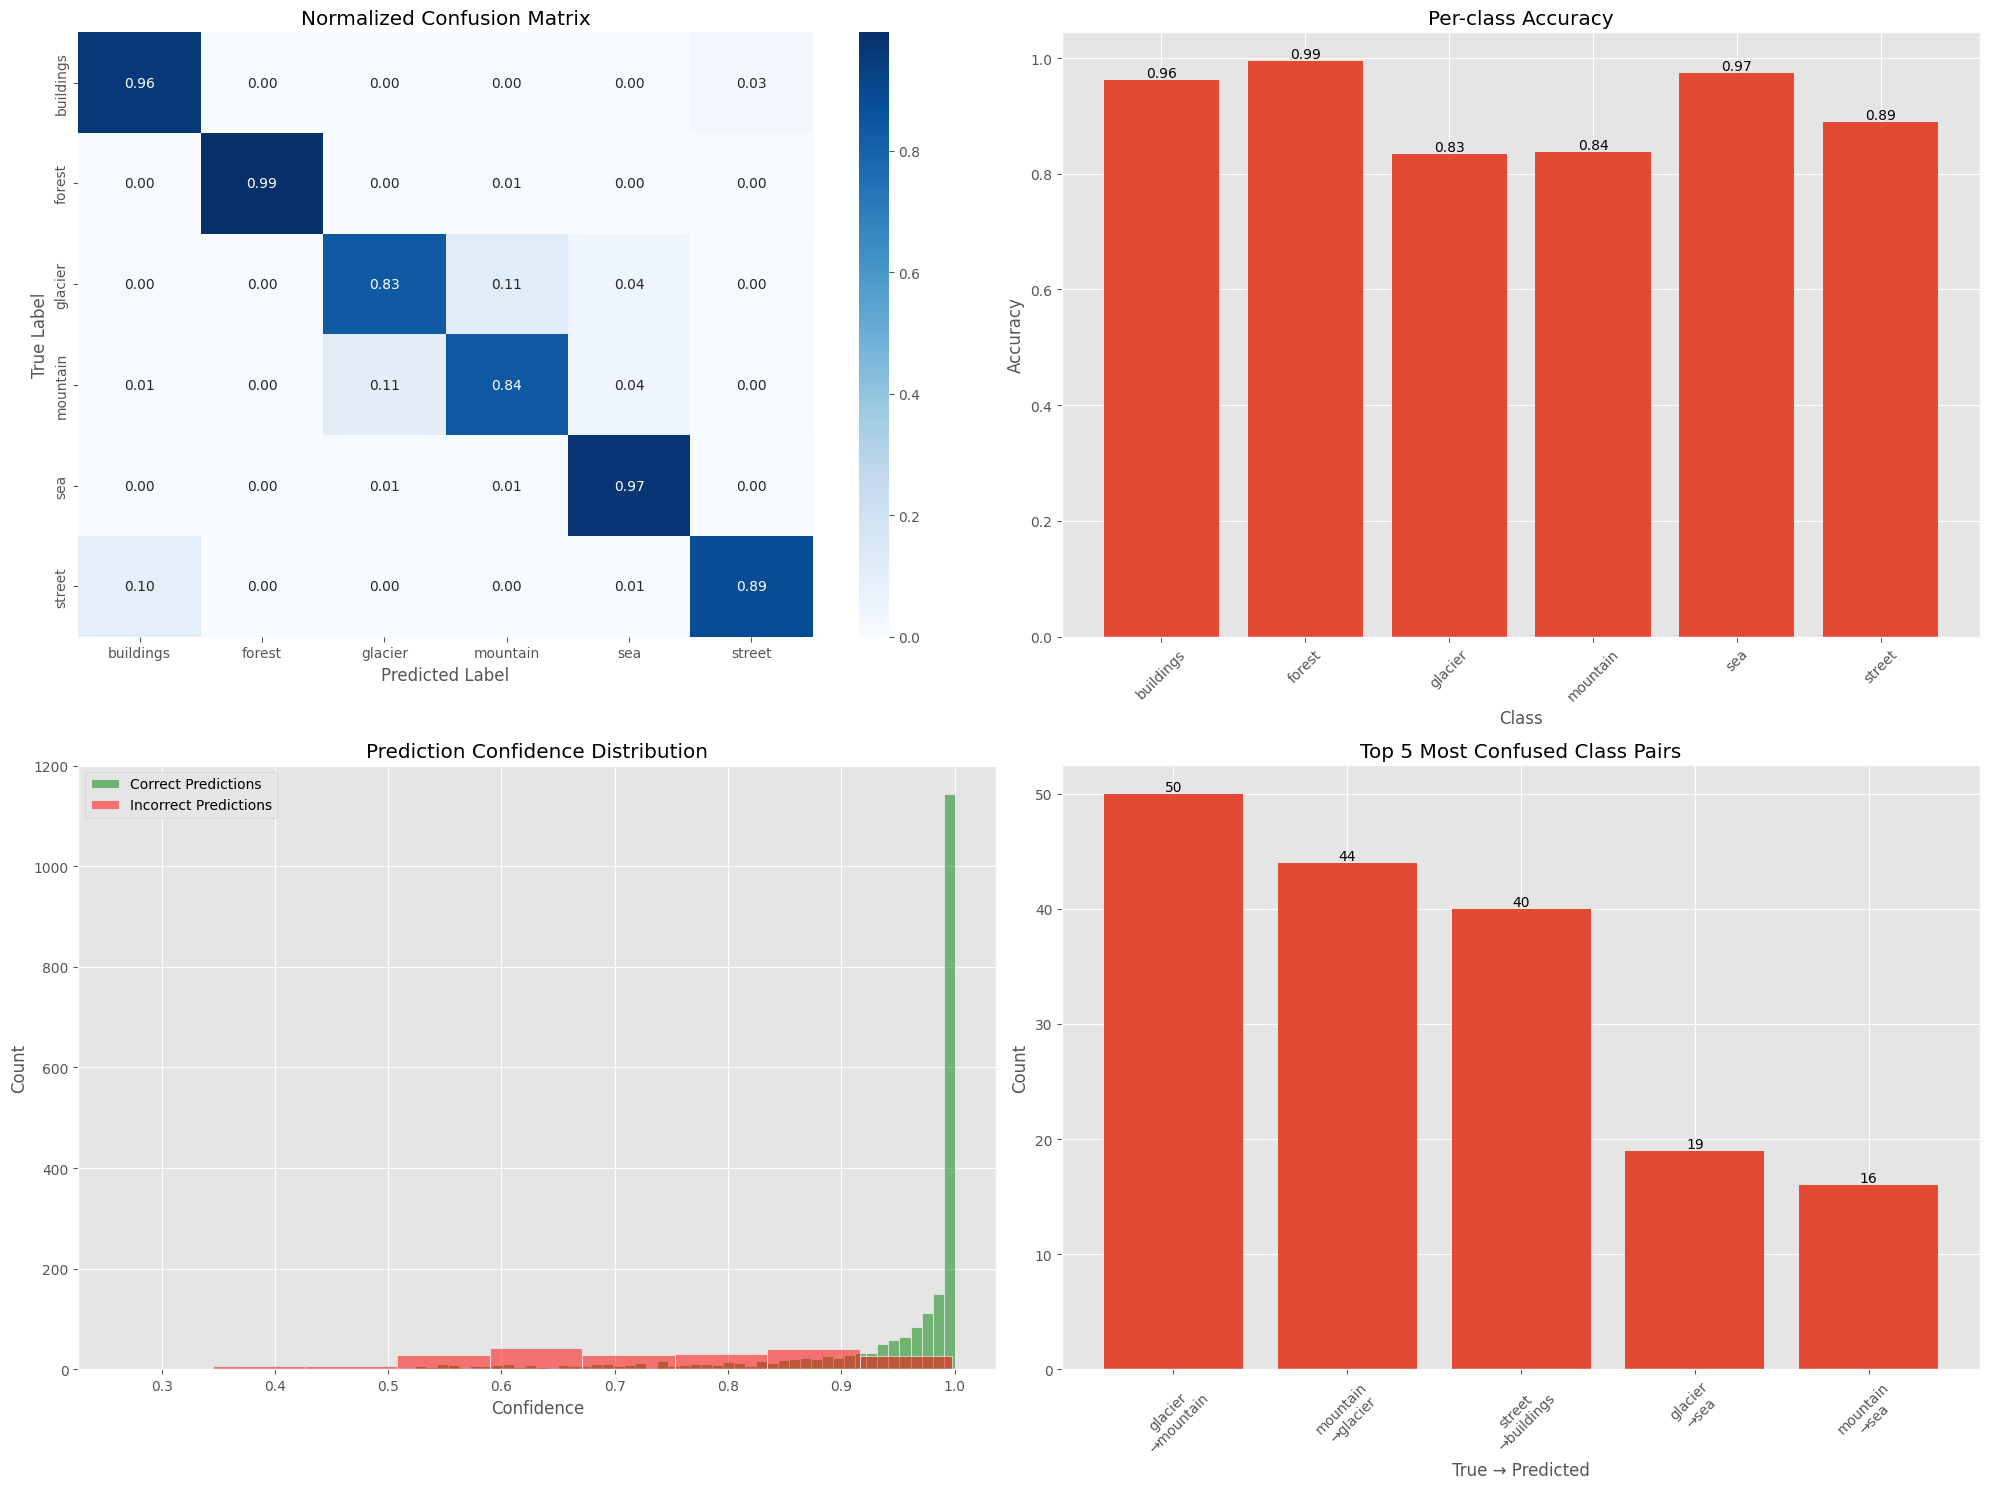


Classification Report:
              precision    recall  f1-score   support

   buildings       0.88      0.96      0.92       364
      forest       0.99      0.99      0.99       374
     glacier       0.88      0.83      0.86       440
    mountain       0.86      0.84      0.85       413
         sea       0.91      0.97      0.94       423
      street       0.96      0.89      0.92       386

    accuracy                           0.91      2400
   macro avg       0.91      0.92      0.91      2400
weighted avg       0.91      0.91      0.91      2400



In [ ]:
resnet_analysis_results = analyze_model_performance(resnet_model, test_ds, class_names)

## CNN Model Ensemble Modelling 🤝

In [25]:
np.random.seed(seed=42)

# number of estimators
n_estimators = 6

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling, Input

models = []
n_random_dense_conv_neurons = np.random.randint(32, 200, size=n_estimators)
n_random_dense_neurons = np.random.randint(50, 200, size=n_estimators)

for i in range(n_estimators):
    model = tf.keras.Sequential([
        Input(INPUT_SHAPE),
        Rescaling(1./255),

        Conv2D(n_random_dense_conv_neurons[i], (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(n_random_dense_neurons[i], activation="relu"),
        tf.keras.layers.Dense(OUTPUT_SHAPE, activation="softmax")
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

    # store model
    models.append(model)

In [27]:
histories = []

for i in range(n_estimators):
    histories.append(
        models[i].fit(
            augmented_train_ds,
            epochs=N_EPOCHS,
            validation_data=val_ds,
            callbacks=[early_stopping]
        )
    )

Epoch 1/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 2137s 5s/step - accuracy: 0.4147 - loss: 12.5484 - val_accuracy: 0.4350 - val_loss: 1.3649
Epoch 2/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 149s 231ms/step - accuracy: 0.5215 - loss: 1.2314 - val_accuracy: 0.5200 - val_loss: 1.3934
Epoch 3/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 141s 229ms/step - accuracy: 0.5445 - loss: 1.1741 - val_accuracy: 0.5317 - val_loss: 1.2915
Epoch 4/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 100s 228ms/step - accuracy: 0.5735 - loss: 1.0993 - val_accuracy: 0.5583 - val_loss: 1.2825
Epoch 5/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 102s 232ms/step - accuracy: 0.5831 - loss: 1.0893 - val_accuracy: 0.5483 - val_loss: 1.2998
Epoch 6/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 102s 231ms/step - accuracy: 0.5947 - loss: 1.0565 - val_accuracy: 0.5583 - val_loss: 1.2331
Epoch 7/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 103s 233ms/step - accuracy: 0.6033 - loss: 1.0392 - val_accuracy: 0.5050 - val_loss: 1.5415
Epoch 1/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 113s 244ms/step - accuracy: 0

In [28]:
pred_accuracies = []

for i in range(n_estimators):
    pred_accuracies.append(models[i].evaluate(test_ds)[1])

best_cnn_model_index = np.argmax(pred_accuracies)
best_accuracy = np.max(pred_accuracies)

print(f"Best CNN Model Accuracy: {best_accuracy:.4f}")
print(f"Best CNN Model Index: {best_cnn_model_index}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 400s 5s/step - accuracy: 0.5174 - loss: 1.4262
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.6487 - loss: 1.0533
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.6002 - loss: 1.2109
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.5898 - loss: 1.1732
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.6016 - loss: 1.0339
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.6257 - loss: 1.0535
Best CNN Model Accuracy: 0.6338
Best CNN Model Index: 1


In [29]:
models[best_cnn_model_index].save(MODEL_SAVE_PATH + "best_cnn_model.keras")

### Best CNN Training History 📈

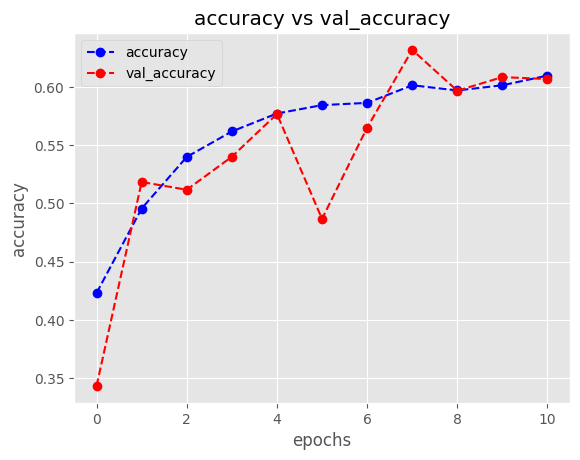

In [35]:
visualize_history_metric(histories[best_cnn_model_index], "accuracy")

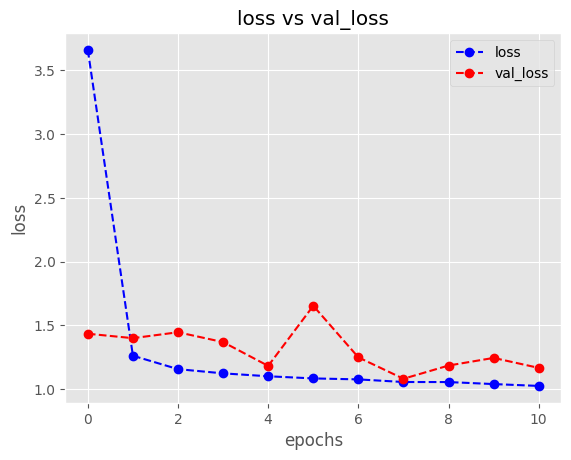

In [36]:
visualize_history_metric(histories[best_cnn_model_index], "loss")

### Best CNN Error Analysis ⚠️

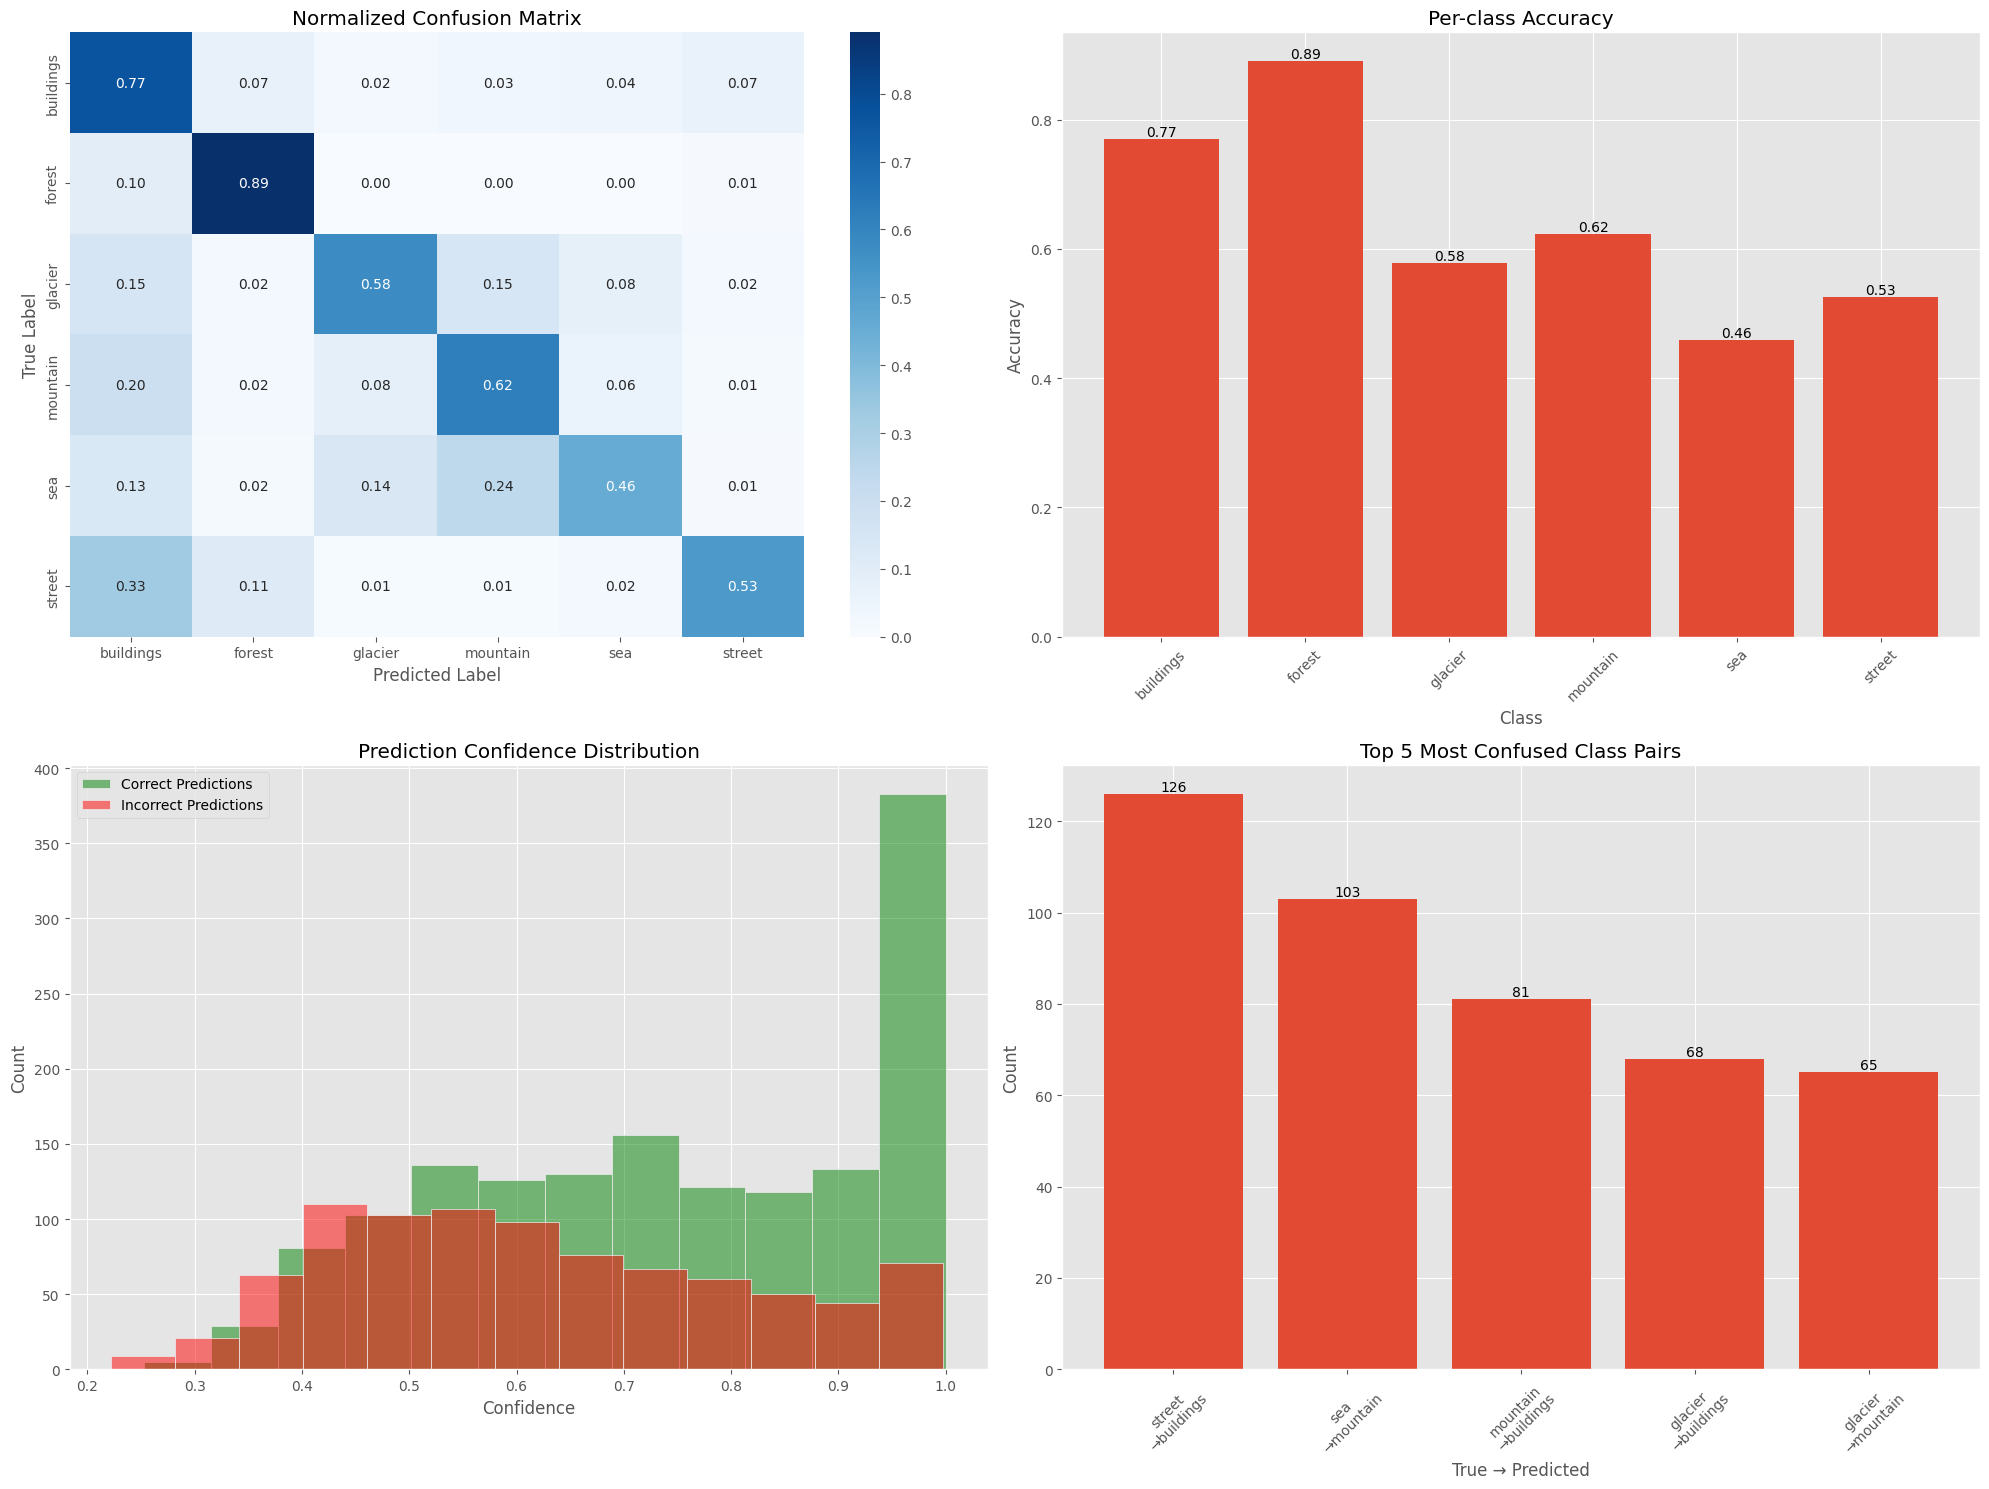


Classification Report:
              precision    recall  f1-score   support

   buildings       0.43      0.77      0.55       364
      forest       0.78      0.89      0.83       374
     glacier       0.71      0.58      0.64       440
    mountain       0.58      0.62      0.60       413
         sea       0.70      0.46      0.55       423
      street       0.81      0.53      0.64       386

    accuracy                           0.63      2400
   macro avg       0.67      0.64      0.64      2400
weighted avg       0.67      0.63      0.63      2400



In [38]:
best_cnn_analysis_results = analyze_model_performance(models[best_cnn_model_index], test_ds, class_names)